In [ ]:
import numpy as np
import math
import matplotlib.pyplot as plt
#import sympy as sym
from scipy.interpolate import interp1d
from scipy import integrate
import matplotlib.patches as mpatches
import pickle

# Start of Hughes Functions
def rISCOpro(a):
    z1 = 1 + (1 - a**2)**(1/3) * ((1+a)**(1/3) + (1-a)**(1/3))
    z2 = (3*a**2 + z1**2)**(1/2)
    r = 3 + z2 - ( (3-z1)*(3 + z1 + 2*z2) )**(1/2)
    return r

def rISCOretro(a):
    z1 = 1 + (1 - a**2)**(1/3) * ((1+a)**(1/3) + (1-a)**(1/3))
    z2 = (3*a**2 + z1**2)**(1/2)
    r = 3 + z2 + ( (3-z1)*(3 + z1 + 2*z2) )**(1/2)
    return r

def EISCOpro(a):
    r = rISCOpro(a)
    n = r**(3/2) -2*r**(1/2) + a
    d = r**(3/4) * (r**(3/2) - 3*r**(1/2) + 2*a)**(1/2)
    if abs(1-a) < 10**-10:
        n = r + r**(1/2) - 1
        d = r**(3/4) * (r**(1/2) + 2)**(1/2)
    E = n/d
    return E

def EISCOretro(a):
    r = rISCOretro(a)
    n = r**(3/2) -2*r**(1/2) - a
    d = r**(3/4) * (r**(3/2) - 3*r**(1/2) - 2*a)**(1/2)
    if abs(1-a) < 10**-10:
        n = r - r**(1/2) - 1
        d = r**(3/4) * (r**(1/2) - 2)**(1/2)
    E = n/d
    return E

def LISCOpro(a):
    r = rISCOpro(a)
    n = r**2-2*a*r**(1/2)+a**2
    d = r**(3/4) * (r**(3/2) - 3*r**(1/2) + 2*a)**(1/2)
    if abs(d) < 10**-10:
        n = r**(3/2) + r + r**(1/2) - 1
        d = r**(3/4) * (r**(1/2) + 2)**(1/2)
    L = n/d
    return L

#Be careful with this function from BDP1972. This returns a negative value. The magnitude of the value is correct.
def LISCOretro(a_star):
    r = rISCOretro(a_star)
    n = -(r**2 + 2*a_star*r**(1/2) + (a_star)**2 )
    d =  ( r**(3/4) * (r**(3/2)-3*r**(1/2)-2*a_star)**(1/2) )
    if abs((d)) < 10**-10:
        n = -(r**(3/2) - r+r**(1/2) + 1 )
        d = ( r**(3/4)*(r**(1/2)-2) ) 
    L = n/d
    return L

def getLz(r, E, a):
    n = E*(r**2-a**2) - (r**2-2*r+a**2)*( r**2*(E**2-1)+r )**(1/2)
    d = a*(r-1)
    Lz = n/d
    return Lz

def getQ(r, E, a):
    Lz = getLz(r, E, a)
    n = (E*(a**2+r**2) - a*Lz)**2
    d = (r**2-2*r+a**2)
    B = r**2 + a**2*E**2 - 2*a*E*Lz + Lz**2
    Q = n/d - B
    return Q

def d2Vr_dr2(E, r, L, a, cosi):
    d2Vr_dr2 =  12*((E**2)-1)*(r**2) + (12*r) + 2*((((E**2) - 1)*(a**2)) - (L**2))
    return d2Vr_dr2

def getHughes(a):
    rpro = rISCOpro(a)
    rretro = rISCOretro(a)
    Epro = EISCOpro(a)
    Eretro = EISCOretro(a)

    Evals = np.linspace(Epro, Eretro, 100)
    rvals = []
    Lvals = []
    cosivals = []
    for E in Evals:
        it = 0
        rmin = rpro
        rmax = rretro
        while it < 1000:
            r = (rmin + rmax) / 2
            Lz = getLz(r, E, a)
            Q = getQ(r, E, a)
            L = (Lz**2+Q)**(1/2)
            cosi = Lz / L
            d2R = d2Vr_dr2(E, r, L, a, cosi)

            if abs(d2R) < 10**-3:
                #print("Found r", r)
                it = 1000
            elif d2R > 0:
                rmin = r
            elif d2R < 0:
                rmax = r
            #if r is to large, it will cause the d2R to become a NaN (sqrt of negative number)
            elif math.isnan(d2R): 
                rmax = r
            it += 1
        rvals.append(r)
        Lvals.append(L)
        cosivals.append(cosi)
    rfunc = interp1d(cosivals, rvals, fill_value = 'extrapolate')
    Efunc = interp1d(cosivals, Evals, fill_value = 'extrapolate')
    Lfunc = interp1d(cosivals, Lvals, fill_value = 'extrapolate')
    return rfunc, Efunc, Lfunc

#End of Hughes Functions



#Start of Taman code for L_cap and L_disruption

#From Taman
def V_rpcap(l, k, i):
    a = 2
    b = - (l)**2
    c = 2*(((l)**2)+(k**2)-(2*k*(l)*i))
    d = - (k**2)*((l)**2)*((1-(i**2)))
    coeff =  [a, b, c, d]
    roots = np.roots(coeff)
    rmax = max(roots)
    if (abs(rmax.imag) < 1e-3):
        rr2 = rmax
    elif (abs(rmax.imag) > 1e-3):
        ind = np.where(roots==rmax)
        roots = np.delete(roots, ind)
        rmaxn = max(roots)
        if (abs(rmaxn.imag) < 1e-3):
            rr2 = rmax
        elif (abs(rmaxn.imag) > 1e-3):
            ind = np.where(roots==rmaxn)
            roots = np.delete(roots, ind)
            rmaxn1 = max(roots)
            rr2 = rmaxn1
    return rr2

#Also from Taman
def getlcapture(k, i, e):
    it = 0
    Lmin = 2
    Lmax = 5
    while it < 100:
        l = (Lmax + Lmin) / 2
        rmax = V_rpcap(l, k, i)
        rh = 1 + ((1 -(k**2))**(1/2)) 
        if (rh < rmax):
            Lmax = l
        if (rh > rmax):
            Lmin = l 
        diff = Lmax - Lmin
        if (abs(diff) < 10**e):
            break
        it += 1
    return Lmax

def get_pericenter(l, k, y):
    a = 2
    b = - (l)**2
    c = 2*(((l)**2)+(k**2)-(2*k*(l)*y))
    d = - (k**2)*((l)**2)*((1-(y**2)))
    coeff =  [a, b, c, d]
    roots = np.roots(coeff)
    rmax = max(roots)
    if (abs(rmax.imag) < 1e-3):
        rr2 = rmax
    elif (abs(rmax.imag) > 1e-3):
        ind = np.where(roots==rmax)
        roots = np.delete(roots, ind)
        rmaxn = max(roots)
        if (abs(rmaxn.imag) < 1e-3):
            rr2 = rmax
        elif (abs(rmaxn.imag) > 1e-3):
            ind = np.where(roots==rmaxn)
            roots = np.delete(roots, ind)
            rmaxn1 = max(roots)
            rr2 = rmaxn1
    return rr2

def getLd(M, k, y, e):
    C = 6.65*10**-17
    lcap = getlcapture(k, y, -10)
    Lmin = lcap
    Lmax = 16
    it = 0
    while it < 1000:
        l = (Lmax + Lmin)/2
        P_r = get_pericenter(l, k, y)
        tides = (1 + (3*((l**2)+(k**2)-(2*k*l*y))/(2*(P_r**2))))*(P_r**-3)
        self_grav = C*(M**2)
        c = tides - self_grav
        if c < 0:
            Lmax = l
        if c > 0:
            Lmin = l
        if abs(c) < 10**e:
            break
        it+=1
    return l

#Taman functions
def get_x0(epsilon, M, xlc):
    sigma = get_sigma(M)
    xc = (1/2*epsilon)*((sigma/(2.998e5))**(2))
    lnlambda = math.log(0.4*M)
    rhrlc = (2/xlc)*((2.998e5/sigma)**(2))
    q = (20/9)*(lnlambda*rhrlc)*(epsilon**-2)/M
    lnxlc = math.log(xlc/xc)
    lnx0 = lnxlc - ((q**2 + q**4)**0.25)
    x0 = xc * math.exp(lnx0)
    return x0

def get_sigma(M):
    s = 200*((M/10**8.32)**(1/5.64))
    return s

def get_triple_diff_lc(e, M ,x0, x):
    Grav_const = 6.67e-11
    M_sun = 1.989e30
    c_speed = 2.998e8
    sec_per_yr = 3.15576e7
    R_sun = 6.96e8
    sigma = get_sigma(M)
    n = np.sqrt(2*e)*((sigma*1000)**5)*sec_per_yr
    d = (c_speed**2)*(M_sun*Grav_const)*np.pi
    xc = (1/2*e)/((sigma/(2.998e5))**(2))
    R = math.log(x/xc)
    R0 = math.log(x0/xc)
    f = 1 - R/R0
    return n*f/d

#Start of get dXdt/dMdt functions

# TDE SIP IP dXdt and dMdt as function of current X and M

def getSIP_IPchange(X, M_BH):
    # TDE SIP + IP
    #M_sun = 1.989e30
    M_sun = 1
    y_arr = np.linspace(-1, 1, 51)
    rfunc, Efunc, Lfunc = getHughes(X)
    drate_dy_X = []
    drate_dy_M = []
    for y in y_arr:
        # Integrate over L from L_cap to L_d
        L_cap = getlcapture(X, y, -3)
        L_d = getLd(M_BH, X, y, -8)
        
        L_d_sq = L_d**2
        L_cap_sq = L_cap**2
        
        if L_d > L_cap:
            # Integrate over e from 1 to 40 (needs to go till infinity but 40 is good enough as the rate falls rapidly)
            e_arr = np.linspace(1, 40, 100)
            
            double_diff_X = []
            double_diff_M = []
            
            for e in e_arr:
                L_LC_sq = max(L_cap_sq, L_d_sq) # loss cone angular momentum squared
                L0_squared = get_x0(epsilon=e, M=M_BH, xlc=L_LC_sq) # Using full loss cone angular momentum to get empty loss cone angular momentum (squared)
                
                if L0_squared > L_d_sq:
                    double_diff_X.append(0)
                    double_diff_M.append(0)
                    continue
                L_sq_arr = np.linspace(max(L_cap**2, L0_squared), L_d**2, 50) # Integrate from max of L_cap^2 and L0^2 to L_d^2
                
                triple_diff_X = []
                triple_diff_M = []
                for L in L_sq_arr:
                    triple_rate = get_triple_diff_lc(e=e, M=M_BH, x0=L0_squared, x=L)
                    N_dot_3_diff_M = triple_rate * (M_sun / 2) * Efunc(y)
                    N_dot_3_diff_X = triple_rate * (Lfunc(y) * y - 2*X*Efunc(y)) / (2*M_BH)

                    triple_diff_X.append(N_dot_3_diff_X)
                    triple_diff_M.append(N_dot_3_diff_M)

                rate_e_X = integrate.simpson(triple_diff_X, x=L_sq_arr)
                rate_e_M = integrate.simpson(triple_diff_M, x=L_sq_arr)
                
                double_diff_X.append(rate_e_X)
                double_diff_M.append(rate_e_M)

            drate_dy_element_X = integrate.simpson(double_diff_X, x=e_arr)
            drate_dy_element_M = integrate.simpson(double_diff_M, x=e_arr)

            drate_dy_X.append(drate_dy_element_X)
            drate_dy_M.append(drate_dy_element_M)
            
        else:
            drate_dy_X.append(0)
            drate_dy_M.append(0)

    total_rate_element_X = integrate.simpson(drate_dy_X, x=y_arr)
    total_rate_element_M = integrate.simpson(drate_dy_M, x=y_arr)

    dXdt = total_rate_element_X
    dMdt = total_rate_element_M

    return dXdt, dMdt

# TDE SIP ISO dXdt and dMdt as function of X and M
def getSIP_ISOchange(X, M_BH):
    # TDE SIP + ISO
    #M_sun = 1.989e30
    M_sun = 1
    y_arr = np.linspace(-1, 1, 101)
    rfunc, Efunc, Lfunc = getHughes(X)
    drate_dy_ISO_X = []
    drate_dy_ISO_M = []
    L_LC_arr = []
    for y in y_arr:
        # Integrate over L from L_cap to L_d
        L_cap = getlcapture(X, y, -3)
        L_d = getLd(M_BH, X, y, -8)
        
        L_d_sq = L_d**2
        L_cap_sq = L_cap**2

        L_LC_sq = max(L_cap_sq, L_d_sq) # loss cone angular momentum squared
        L_LC_arr.append(L_LC_sq)

    L_LC_avg_sq = np.mean(L_LC_arr)

    for y in y_arr:
        # Integrate over L from L_cap to L_d
        L_cap = getlcapture(X, y, -3)
        L_d = getLd(M_BH, X, y, -8)
        
        L_d_sq = L_d**2
        L_cap_sq = L_cap**2
        
        
        if L_d > L_cap:
            # Integrate over e from 1 to 60 (needs to go till infinity but 60 is good enough as the rate falls rapidly)
            e_arr = np.linspace(1, 60, 200)

            double_diff_ISO_X = []
            double_diff_ISO_M = []

            for e in e_arr:

                L0_norm_sq = get_x0(epsilon=e, M=M_BH, xlc=L_LC_avg_sq) # Normalized empty loss cone angular momentum squared - ISOTROPIZING

                L_sq_arr = np.linspace(max(L_cap**2, L0_norm_sq), L_d**2, 51) # Integrate from max of L_cap^2 and L0^2 to L_d^2
                
                if L0_norm_sq > L_d**2:
                    double_diff_ISO_X.append(0)
                    double_diff_ISO_M.append(0)
                    continue

                triple_diff_ISO_X = []
                triple_diff_ISO_M = []
                for L in L_sq_arr:
                    triple_rate = get_triple_diff_lc(e=e, M=M_BH, x0=L0_norm_sq, x=L)

                    N_dot_3_diff_M = triple_rate * (M_sun / 2) * Efunc(y)
                    N_dot_3_diff_X = triple_rate *  (Lfunc(y) * y - 2*X*Efunc(y)) / (2*M_BH)

                    triple_diff_ISO_X.append(N_dot_3_diff_X)
                    triple_diff_ISO_M.append(N_dot_3_diff_M)

                rate_e_ISO_X = integrate.simpson(triple_diff_ISO_X, x=L_sq_arr)
                rate_e_ISO_M = integrate.simpson(triple_diff_ISO_M, x=L_sq_arr)

                double_diff_ISO_X.append(rate_e_ISO_X)
                double_diff_ISO_M.append(rate_e_ISO_M)

            drate_dy_element_ISO_X = integrate.simpson(double_diff_ISO_X, x=e_arr)
            drate_dy_element_ISO_M = integrate.simpson(double_diff_ISO_M, x=e_arr)

            drate_dy_ISO_X.append(drate_dy_element_ISO_X)
            drate_dy_ISO_M.append(drate_dy_element_ISO_M)

        else:
            drate_dy_ISO_X.append(0)
            drate_dy_ISO_M.append(0)

    total_rate_element_ISO_X = integrate.simpson(drate_dy_ISO_X, x=y_arr)
    total_rate_element_ISO_M = integrate.simpson(drate_dy_ISO_M, x=y_arr)
    
    dXdt = total_rate_element_ISO_X
    dMdt = total_rate_element_ISO_M
    
    return dXdt, dMdt


# TDE EQU IP dXdt and dMdt as function of X and M
def getEQU_IPchange(X, M_BH):
    # TDE EQU + IP
    #M_sun = 1.989e30
    M_sun = 1
    y_arr = np.linspace(-1, 1, 51)
    rfunc, Efunc, Lfunc = getHughes(X)
        
    drate_dy_X = []
    drate_dy_M = []
    for y in y_arr:
        # Integrate over L from L_cap to L_d
        L_cap = getlcapture(X, y, -3)
        L_d = getLd(M_BH, X, y, -8)
        
        L_d_sq = L_d**2
        L_cap_sq = L_cap**2
        
        if L_d > L_cap:
            # Integrate over e from 1 to 40 (needs to go till infinity but 40 is good enough as the rate falls rapidly)
            e_arr = np.linspace(1, 40, 100)
            
            double_diff_X = []
            double_diff_M = []
            
            for e in e_arr:
                L_LC_sq = max(L_cap_sq, L_d_sq) # loss cone angular momentum squared
                L0_squared = get_x0(epsilon=e, M=M_BH, xlc=L_LC_sq) # Using full loss cone angular momentum to get empty loss cone angular momentum (squared)
                
                if L0_squared > L_d_sq:
                    double_diff_X.append(0)
                    double_diff_M.append(0)
                    continue
                L_sq_arr = np.linspace(max(L_cap**2, L0_squared), L_d**2, 50) # Integrate from max of L_cap^2 and L0^2 to L_d^2
                
                triple_diff_X = []
                triple_diff_M = []
                for L in L_sq_arr:

                    if np.sqrt(L)*y > Lfunc(1)*1:
                        cosiisco = 1
                        Eisco = Efunc(1)
                        Lisco = Lfunc(1)
                        #print("above")
                    elif np.sqrt(L)*y < Lfunc(-1)*-1:
                        cosiisco = -1
                        Eisco = Efunc(-1)
                        Lisco = Lfunc(-1)
                        #print("below")
                    elif (np.sqrt(L)*y > Lfunc(-1)*-1) and (np.sqrt(L)*y < Lfunc(1)*1):
                        #figure out X function
                        cosi_min = -1
                        cosi_max = 1
                        it = 0
                        while it < 1000:
                            cosi_guess = (cosi_min + cosi_max ) / 2
                            Lc_guess = Lfunc(cosi_guess)*cosi_guess
                            if abs(np.sqrt(L)*y - Lc_guess) < 10**-5:
                                break
                            elif np.sqrt(L)*y < Lc_guess:
                                cosi_max = cosi_guess
                            elif np.sqrt(L)*y > Lc_guess:
                                cosi_min = cosi_guess
                            it += 1
                        cosiisco = cosi_guess
                        Eisco = Efunc(cosiisco)
                        Lisco = Lfunc(cosiisco)

                    triple_rate = get_triple_diff_lc(e=e, M=M_BH, x0=L0_squared, x=L)
                    N_dot_3_diff_M = triple_rate * (M_sun / 2) * Efunc(y)
                    N_dot_3_diff_X = triple_rate * (Lisco * cosiisco - 2*X*Eisco) / (2*M_BH)
                
                    triple_diff_X.append(N_dot_3_diff_X)
                    triple_diff_M.append(N_dot_3_diff_M)

                rate_e_X = integrate.simpson(triple_diff_X, x=L_sq_arr)
                rate_e_M = integrate.simpson(triple_diff_M, x=L_sq_arr)
                
                double_diff_X.append(rate_e_X)
                double_diff_M.append(rate_e_M)

            drate_dy_element_X = integrate.simpson(double_diff_X, x=e_arr)
            drate_dy_element_M = integrate.simpson(double_diff_M, x=e_arr)

            drate_dy_X.append(drate_dy_element_X)
            drate_dy_M.append(drate_dy_element_M)
            
        else:
            drate_dy_X.append(0)
            drate_dy_M.append(0)

    total_rate_element_X = integrate.simpson(drate_dy_X, x=y_arr)
    total_rate_element_M = integrate.simpson(drate_dy_M, x=y_arr)

    dXdt = total_rate_element_X
    dMdt = total_rate_element_M
    
    return dXdt, dMdt


# TDE EQU ISO dXdt and dMdt as function of X and M

def getEQU_ISOchange(X, M_BH):
    #M_sun = 1.989e30
    M_sun = 1
    y_arr = np.linspace(-1, 1, 101)
    rfunc, Efunc, Lfunc = getHughes(X)
    drate_dy_ISO_X = []
    drate_dy_ISO_M = []
    L_LC_arr = []
    for y in y_arr:
        # Integrate over L from L_cap to L_d
        L_cap = getlcapture(X, y, -3)
        L_d = getLd(M_BH, X, y, -8)
        
        L_d_sq = L_d**2
        L_cap_sq = L_cap**2

        L_LC_sq = max(L_cap_sq, L_d_sq) # loss cone angular momentum squared
        L_LC_arr.append(L_LC_sq)

    L_LC_avg_sq = np.mean(L_LC_arr)

    for y in y_arr:
        # Integrate over L from L_cap to L_d
        L_cap = getlcapture(X, y, -3)
        L_d = getLd(M_BH, X, y, -8)
        
        L_d_sq = L_d**2
        L_cap_sq = L_cap**2
        
        
        if L_d > L_cap:
            # Integrate over e from 1 to 60 (needs to go till infinity but 60 is good enough as the rate falls rapidly)
            e_arr = np.linspace(1, 60, 200)

            double_diff_ISO_X = []
            double_diff_ISO_M = []

            for e in e_arr:

                L0_norm_sq = get_x0(epsilon=e, M=M_BH, xlc=L_LC_avg_sq) # Normalized empty loss cone angular momentum squared - ISOTROPIZING

                L_sq_arr = np.linspace(max(L_cap**2, L0_norm_sq), L_d**2, 51) # Integrate from max of L_cap^2 and L0^2 to L_d^2
                
                if L0_norm_sq > L_d**2:
                    double_diff_ISO_X.append(0)
                    double_diff_ISO_M.append(0)
                    continue

                triple_diff_ISO_X = []
                triple_diff_ISO_M = []
                for L in L_sq_arr:

                    if np.sqrt(L)*y > Lfunc(1)*1:
                        cosiisco = 1
                        Eisco = Efunc(1)
                        Lisco = Lfunc(1)
                        #print("above")
                    elif np.sqrt(L)*y < Lfunc(-1)*-1:
                        cosiisco = -1
                        Eisco = Efunc(-1)
                        Lisco = Lfunc(-1)
                        #print("below")
                    elif (np.sqrt(L)*y > Lfunc(-1)*-1) and (np.sqrt(L)*y < Lfunc(1)*1):
                        #figure out X function
                        cosi_min = -1
                        cosi_max = 1
                        it = 0
                        while it < 1000:
                            cosi_guess = (cosi_min + cosi_max ) / 2
                            Lc_guess = Lfunc(cosi_guess)*cosi_guess
                            if abs(np.sqrt(L)*y - Lc_guess) < 10**-5:
                                break
                            elif np.sqrt(L)*y < Lc_guess:
                                cosi_max = cosi_guess
                            elif np.sqrt(L)*y > Lc_guess:
                                cosi_min = cosi_guess
                            it += 1
                        cosiisco = cosi_guess
                        Eisco = Efunc(cosiisco)
                        Lisco = Lfunc(cosiisco)

        
                    triple_rate = get_triple_diff_lc(e=e, M=M_BH, x0=L0_norm_sq, x=L)
                    N_dot_3_diff_X = triple_rate *(Lisco * cosiisco - 2*X*Eisco) / (2*M_BH)
                    N_dot_3_diff_M = triple_rate * (M_sun / 2) * Efunc(y)

                    triple_diff_ISO_X.append(N_dot_3_diff_X)
                    triple_diff_ISO_M.append(N_dot_3_diff_M)

                rate_e_ISO_X = integrate.simpson(triple_diff_ISO_X, x=L_sq_arr)
                rate_e_ISO_M = integrate.simpson(triple_diff_ISO_M, x=L_sq_arr)
                double_diff_ISO_X.append(rate_e_ISO_X)
                double_diff_ISO_M.append(rate_e_ISO_M)

            drate_dy_element_ISO_X = integrate.simpson(double_diff_ISO_X, x=e_arr)
            drate_dy_element_ISO_M = integrate.simpson(double_diff_ISO_M, x=e_arr)

            drate_dy_ISO_X.append(drate_dy_element_ISO_X)
            drate_dy_ISO_M.append(drate_dy_element_ISO_M)

        else:
            drate_dy_ISO_X.append(0)
            drate_dy_ISO_M.append(0)

    total_rate_element_ISO_X = integrate.simpson(drate_dy_ISO_X, x=y_arr)
    total_rate_element_ISO_M = integrate.simpson(drate_dy_ISO_M, x=y_arr)

    dXdt = total_rate_element_ISO_X
    dMdt = total_rate_element_ISO_M
    
    return dXdt, dMdt

# CAP IP dXdt and dMdt as function of X and M
def getCAP_IPchange(X, M_BH):
    #M_sun = 1.989e30
    M_sun = 1
    y_arr = np.linspace(-1, 1, 51)

    rfunc, Efunc, Lfunc = getHughes(X)

    drate_dy_X = []
    drate_dy_M = []
    for y in y_arr:

        L_cap = getlcapture(X, y, -3)
        L_d = getLd(M_BH, X, y, -8)
        
        L_d_sq = L_d**2
        L_cap_sq = L_cap**2
        
            # Integrate over e from 1 to 40 (needs to go till infinity but 40 is good enough as the rate falls rapidly)
        e_arr = np.linspace(1, 40, 100)
        
        double_diff_X = []
        double_diff_M = []
        
        for e in e_arr:
            L_LC_sq = max(L_cap_sq, L_d_sq) # loss cone angular momentum squared
            L0_squared = get_x0(epsilon=e, M=M_BH, xlc=L_LC_sq) # Using full loss cone angular momentum to get empty loss cone angular momentum (squared)
            
            if L0_squared > L_cap_sq: #changed this here from L_d_sq to L_cap_sq
                double_diff_X.append(0)
                double_diff_M.append(0)
                continue
            #changed this here, too got rid of max function and set upper limit to L_cap_sq
            L_sq_arr = np.linspace(L0_squared, L_cap_sq, 50) # Integrate from max of L_cap^2 and L0^2 to L_d^2
            
            triple_diff_X = []
            triple_diff_M = []
            for L in L_sq_arr:

                triple_rate = get_triple_diff_lc(e=e, M=M_BH, x0=L0_squared, x=L)
                N_dot_3_diff_X = triple_rate * (np.sqrt(L) * y - 2*X)/(M_BH)
                N_dot_3_diff_M = triple_rate * (M_sun)


                triple_diff_X.append(N_dot_3_diff_X)
                triple_diff_M.append(N_dot_3_diff_M)

            rate_e_X = integrate.simpson(triple_diff_X, x=L_sq_arr)
            rate_e_M = integrate.simpson(triple_diff_M, x=L_sq_arr)
            
            double_diff_X.append(rate_e_X)
            double_diff_M.append(rate_e_M)

        drate_dy_element_X = integrate.simpson(double_diff_X, x=e_arr)
        drate_dy_element_M = integrate.simpson(double_diff_M, x=e_arr)

        drate_dy_X.append(drate_dy_element_X)
        drate_dy_M.append(drate_dy_element_M)

    total_rate_element_X = integrate.simpson(drate_dy_X, x=y_arr)
    total_rate_element_Y = integrate.simpson(drate_dy_M, x=y_arr)

    dXdt = total_rate_element_X
    dMdt = total_rate_element_Y
    
    return dXdt, dMdt



# CAP ISO dXdt and dMdt as function of X and M

def getCAP_ISOchange(X, M_BH):
    #M_sun = 1.989e30
    M_sun = 1
    y_arr = np.linspace(-1, 1, 101)

    rfunc, Efunc, Lfunc = getHughes(X)
    drate_dy_ISO_X = []
    drate_dy_ISO_M = []
    L_LC_arr = []
    for y in y_arr:
        # Integrate over L from L_cap to L_d
        L_cap = getlcapture(X, y, -3)
        L_d = getLd(M_BH, X, y, -8)
        
        L_d_sq = L_d**2
        L_cap_sq = L_cap**2

        L_LC_sq = max(L_cap_sq, L_d_sq) # loss cone angular momentum squared
        L_LC_arr.append(L_LC_sq)

    L_LC_avg_sq = np.mean(L_LC_arr)

    for y in y_arr:
        # Integrate over L from L_cap to L_d
        L_cap = getlcapture(X, y, -3)
        L_d = getLd(M_BH, X, y, -8)
        
        L_d_sq = L_d**2
        L_cap_sq = L_cap**2
        
  
        # Integrate over e from 1 to 60 (needs to go till infinity but 60 is good enough as the rate falls rapidly)
        e_arr = np.linspace(1, 60, 200)

        double_diff_ISO_X = []
        double_diff_ISO_M = []

        for e in e_arr:

            L0_norm_sq = get_x0(epsilon=e, M=M_BH, xlc=L_LC_avg_sq) # Normalized empty loss cone angular momentum squared - ISOTROPIZING

            L_sq_arr = np.linspace(L0_norm_sq, L_cap_sq, 51) # changed upper limit to L_cap_sq
            
            if L0_norm_sq > L_cap_sq: # changed this here from L_d**2 to L_cap_sq
                double_diff_ISO_X.append(0)
                double_diff_ISO_M.append(0)
                continue

            triple_diff_ISO_X = []
            triple_diff_ISO_M = []

            for L in L_sq_arr:
                triple_rate = get_triple_diff_lc(e=e, M=M_BH, x0=L0_norm_sq, x=L)

                N_dot_3_diff_X = triple_rate * (np.sqrt(L) * y - 2*X)/(M_BH)
                N_dot_3_diff_M = triple_rate * (M_sun)

                triple_diff_ISO_X.append(N_dot_3_diff_X)
                triple_diff_ISO_M.append(N_dot_3_diff_M)

            rate_e_ISO_X = integrate.simpson(triple_diff_ISO_X, x=L_sq_arr)
            rate_e_ISO_M = integrate.simpson(triple_diff_ISO_M, x=L_sq_arr)

            double_diff_ISO_X.append(rate_e_ISO_X)
            double_diff_ISO_M.append(rate_e_ISO_M)

        drate_dy_element_ISO_X = integrate.simpson(double_diff_ISO_X, x=e_arr)
        drate_dy_element_ISO_M = integrate.simpson(double_diff_ISO_M, x=e_arr)

        drate_dy_ISO_X.append(drate_dy_element_ISO_X)
        drate_dy_ISO_M.append(drate_dy_element_ISO_M)


    total_rate_element_ISO_X = integrate.simpson(drate_dy_ISO_X, x=y_arr)
    total_rate_element_ISO_M = integrate.simpson(drate_dy_ISO_M, x=y_arr)

    dXdt = total_rate_element_ISO_X
    dMdt = total_rate_element_ISO_M

    return dXdt, dMdt




C:\Users\Austin\AppData\Local\Temp\ipykernel_42368\3839145062.py:64: RuntimeWarning: invalid value encountered in scalar power
  n = E*(r**2-a**2) - (r**2-2*r+a**2)*( r**2*(E**2-1)+r )**(1/2)


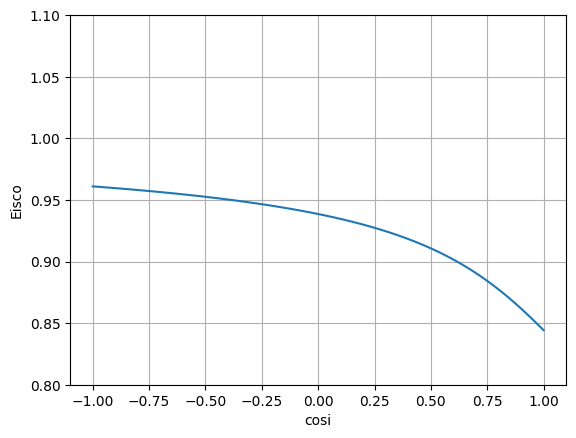

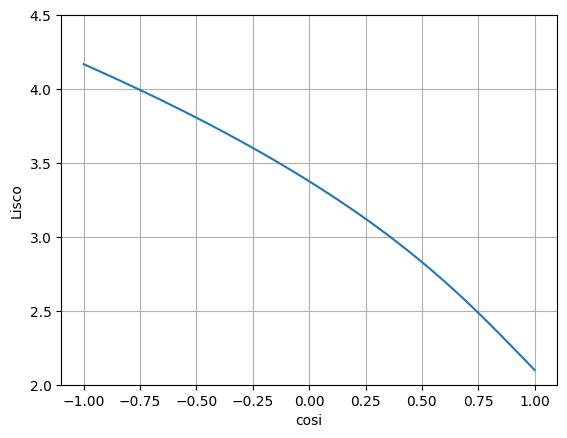

Prograde ISCO:
0.8442470112739985 2.0997847706702775
0.844247008005536 2.099784756123846
Retrograde ISCO:
0.9610016543935472 4.168064197286052
0.961001654354718 -4.168064196332359


In [45]:
X = 0.9
rfunc, Efunc, Lfunc = getHughes(X)

cosi = np.linspace(-1, 1, 100)
Eisco_values = []
Lisco_values = []
for c in cosi:
    Eisco_values.append(Efunc(c))
    Lisco_values.append(Lfunc(c))
plt.plot(cosi, Eisco_values)
plt.xlabel("cosi")
plt.ylabel("Eisco")
plt.grid()
plt.ylim(0.8, 1.1)
plt.show()

plt.plot(cosi, Lisco_values)
plt.xlabel("cosi")
plt.ylabel("Lisco")
plt.grid()
plt.ylim(2, 4.5)
plt.show()

print('Prograde ISCO:')
print(Efunc(1), Lfunc(1))
print(EISCOpro(X), LISCOpro(X))

print('Retrograde ISCO:')
print(Efunc(-1), Lfunc(-1))
print(EISCOretro(X), LISCOretro(X))
